In [4]:
import numpy as np

# Example:
A = np.array([
    [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1]
])

y = np.array([1087, 1008, 1068, 1204, 1158, 1151, 1143]).reshape(-1, 1)

# Matrix multiplication
#result1 = A @ A.T      # 7x28 times 28x7 -> 7x7
result2 = A.T @ y      # 28x7 times 7x1 -> 28x1
#result3 = A @ (A.T @ y)  # 7x28 times 28x1 -> 7x1

#print("A @ A.T =\n", result1)
print("\nA.T @ y =\n", result2)
#print("\nA @ (A.T @ y) =\n", result3)


A.T @ y =
 [[1087]
 [2095]
 [3163]
 [4367]
 [5525]
 [6676]
 [7819]
 [1008]
 [2076]
 [3280]
 [4438]
 [5589]
 [6732]
 [1068]
 [2272]
 [3430]
 [4581]
 [5724]
 [1204]
 [2362]
 [3513]
 [4656]
 [1158]
 [2309]
 [3452]
 [1151]
 [2294]
 [1143]]


In [2]:
y

array([[1087],
       [1008],
       [1068],
       [1204],
       [1158],
       [1151],
       [1143]])

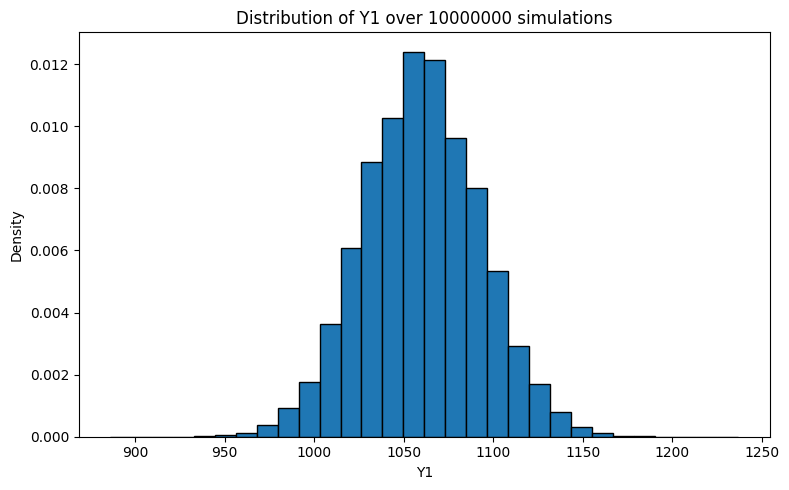

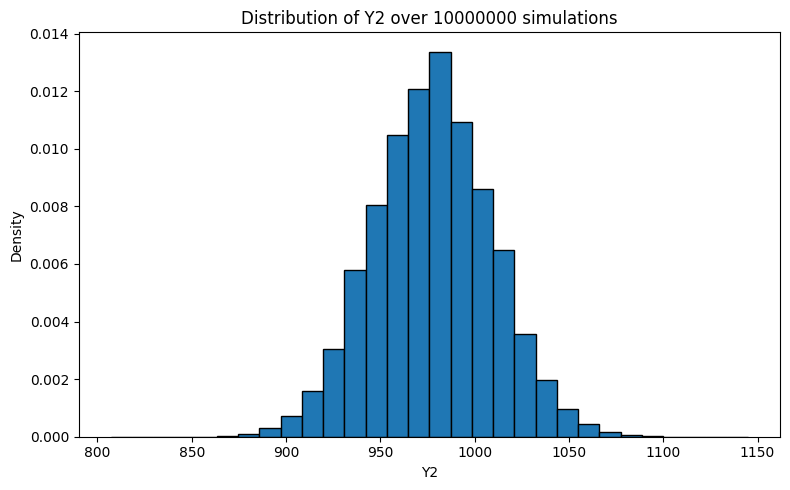

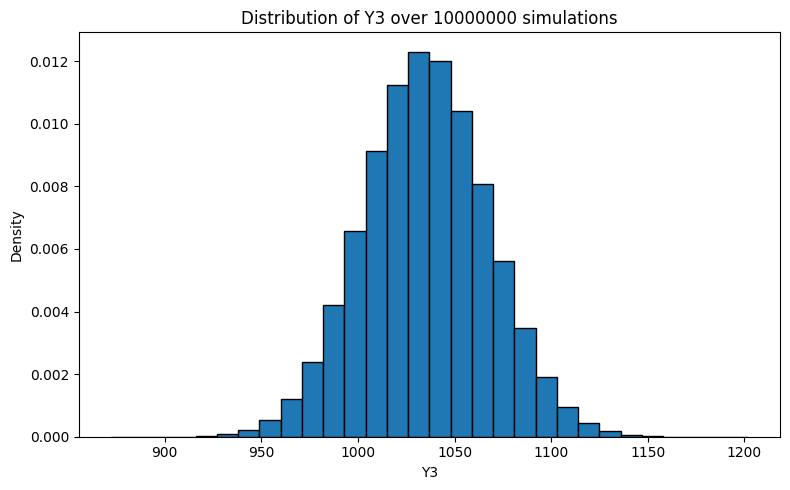

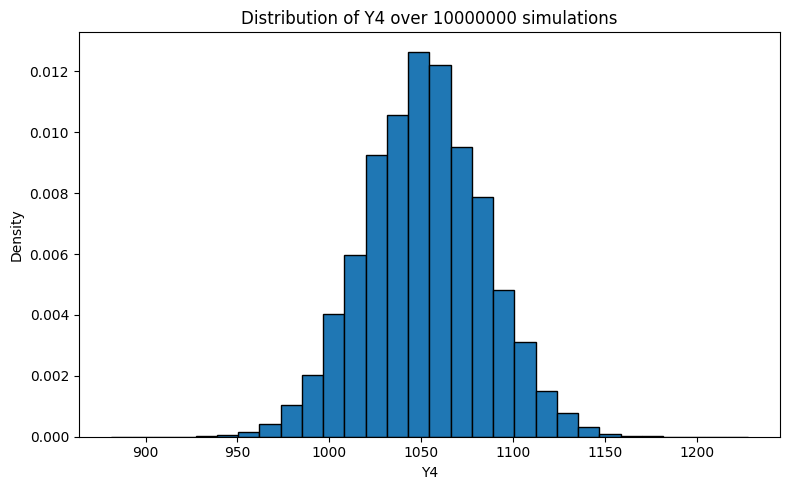

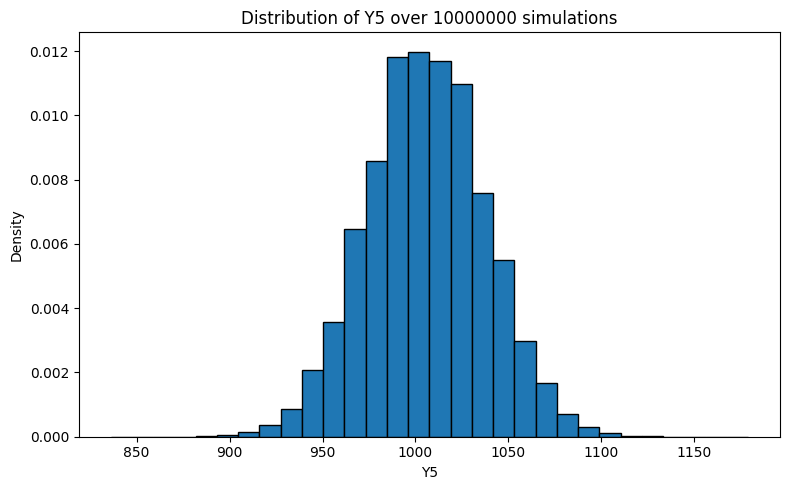

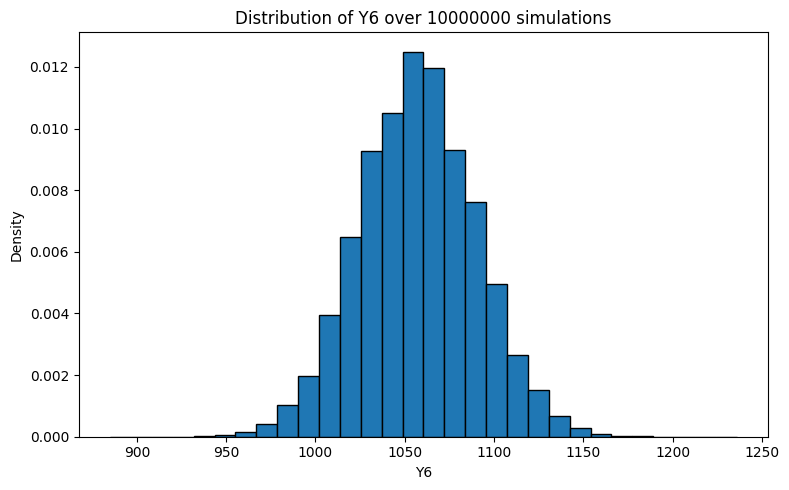

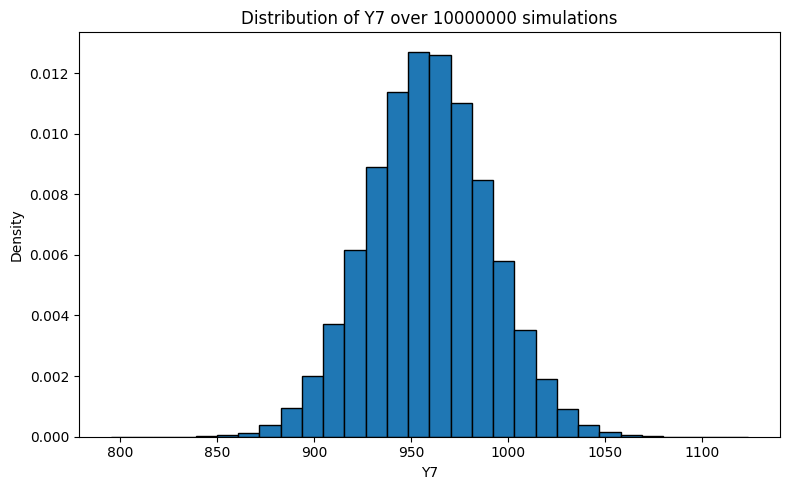

Average Y values:
Y1: 1059.99
Y2: 977.59
Y3: 1034.59
Y4: 1051.90
Y5: 1005.70
Y6: 1057.19
Y7: 958.99


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n_sim = 10000000

# 7 x 28 configuration matrix A
A = np.array([
    [1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,1,1,1,1,0,0,1,1,1,0,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0],
    [0,0,0,0,1,1,1,0,0,0,1,1,0,0,1,1,1,0,1,1,1,1,1,0,0,0,0,0],
    [0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,1,1,0,0,1,0,1,1,1,1,0,0,0],
    [0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,1,1]
], dtype=int)

# Poisson means for the 28 OD flows
theta = np.array([
    83.0, 25.0, 19.0, 89.0, 10.0,  9.0, 825.0,
            0.1,  0.1,  0.1,  0.1,  0.1,  0.1,
                  0.1,  5.0,  1.0,  2.0, 74.0,
                       0.5, 36.0,  2.0, 105.0,
                             10.0,  0.1, 69.0,
                                    5.0, 38.0,
                                        15.0
])

# Simulate 1000 X vectors
X_sims = np.random.poisson(lam=theta, size=(n_sim, len(theta)))

# Compute Y = AX for each simulation
Y_sims = X_sims @ A.T   # shape: (1000, 7)

# Plot distributions of Y1,...,Y7
for i in range(7):
    plt.figure(figsize=(8, 5))
    plt.hist(Y_sims[:, i], bins=30, edgecolor='black', density=True)
    plt.xlabel(f"Y{i+1}")
    plt.ylabel("Density")
    plt.title(f"Distribution of Y{i+1} over {n_sim} simulations")
    plt.tight_layout()
    plt.show()

print("Average Y values:")
for i in range(7):
    print(f"Y{i+1}: {Y_sims[:, i].mean():.2f}")

In [11]:
import numpy as np

y_obs = np.array([1087, 1008, 1068, 1204, 1158, 1151, 1143])

y_mean = Y_sims.mean(axis=0)
y_std = Y_sims.std(axis=0, ddof=1)   # sample std

z_scores = (y_obs - y_mean) / y_std

print("Means:", y_mean)
print("Standard deviations:", y_std)
print("Z-scores (number of SDs from the mean):", z_scores)

for i, z in enumerate(z_scores, start=1):
    print(f"Y{i}: {z:.2f} standard deviations from the mean")

Means: [1059.9934207  977.5903955 1034.5908852 1051.8966499 1005.6952994
 1057.1911151  958.9909209]
Standard deviations: [32.54566419 31.25688663 32.15297466 32.41808353 31.70274587 32.50780799
 30.96463879]
Z-scores (number of SDs from the mean): [0.82980575 0.97289295 1.03906762 4.69192912 4.80414855 2.88573394
 5.94255532]
Y1: 0.83 standard deviations from the mean
Y2: 0.97 standard deviations from the mean
Y3: 1.04 standard deviations from the mean
Y4: 4.69 standard deviations from the mean
Y5: 4.80 standard deviations from the mean
Y6: 2.89 standard deviations from the mean
Y7: 5.94 standard deviations from the mean
